In [1]:
import numpy as np
import pandas as pd

In [2]:
birth = pd.read_csv("us_births_2016_2021.csv")
birth

,State,State Abbreviation,Year,Gender,Education Level of Mother,Education Level Code,Number of Births,Average Age of Mother (years),Average Birth Weight (g)
0,Alabama,AL,2016,F,8th grade or less,1,1052,27.8,3116.9
1,Alabama,AL,2016,F,9th through 12th grade with no diploma,2,3436,24.1,3040.0
2,Alabama,AL,2016,F,High school graduate or GED completed,3,8777,25.4,3080.0
3,Alabama,AL,2016,F,"Some college credit, but not a degree",4,6453,26.7,3121.9
4,Alabama,AL,2016,F,"Associate degree (AA, AS)",5,2227,28.9,3174.3
...,...,...,...,...,...,...,...,...,...
5491,Wyoming,WY,2021,M,"Associate degree (AA, AS)",5,401,29.2,3261.1
5492,Wyoming,WY,2021,M,"Bachelor's degree (BA, AB, BS)",6,657,30.7,3286.0
5493,Wyoming,WY,2021,M,"Master's degree (MA, MS, MEng, MEd, MSW, MBA)",7,261,33.0,3249.3
5494,Wyoming,WY,2021,M,"Doctorate (PhD, EdD) or Professional Degree (M...",8,72,33.3,3262.0


In [6]:
birth.isna().sum()

State                            0
State Abbreviation               0
Year                             0
Gender                           0
Education Level of Mother        0
Education Level Code             0
Number of Births                 0
Average Age of Mother (years)    0
Average Birth Weight (g)         0
dtype: int64

In [4]:
state_year = birth.groupby(["State", "Year"])["Number of Births"].sum()
state_year = state_year.reset_index()
state_year


,State,Year,Number of Births
0,Alabama,2016,59151
1,Alabama,2017,58941
2,Alabama,2018,57761
3,Alabama,2019,58615
4,Alabama,2020,57647
...,...,...,...
301,Wyoming,2017,6903
302,Wyoming,2018,6562
303,Wyoming,2019,6565
304,Wyoming,2020,6128


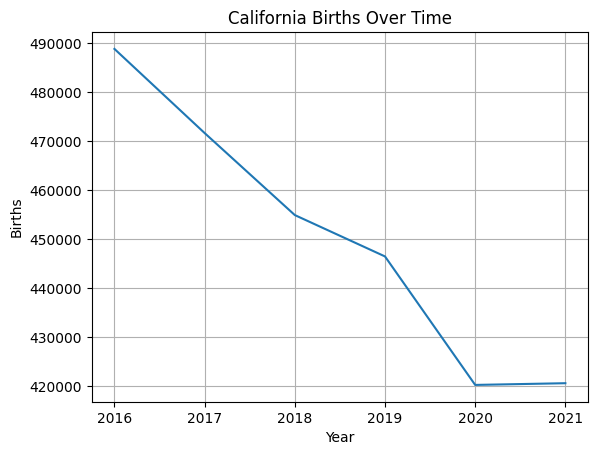

In [ ]:
import matplotlib.pyplot as plt

ca = state_year[state_year["State"] == "California"]

plt.plot(ca["Year"], ca["Number of Births"])
plt.title("California Births Over Time")
plt.xlabel("Year")
plt.ylabel("Births")
plt.grid(True)


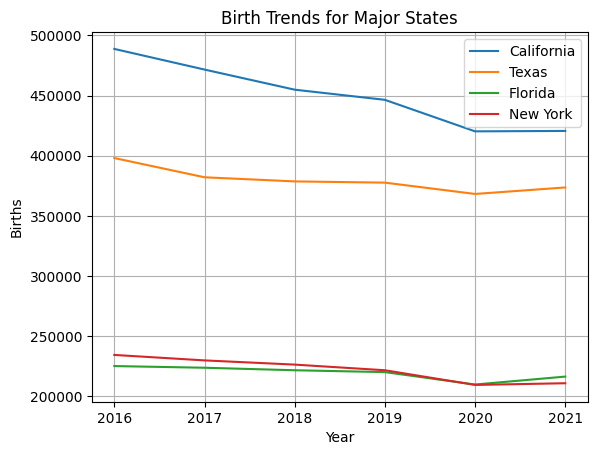

In [7]:
top_states = ["California", "Texas", "Florida", "New York"]

for s in top_states:
    subset = state_year[state_year["State"] == s]
    plt.plot(subset["Year"], subset["Number of Births"], label=s)

plt.legend()
plt.title("Birth Trends for Major States")
plt.xlabel("Year")
plt.ylabel("Births")
plt.grid(True)


In [8]:
gender_state_year = birth.groupby(["State", "Year", "Gender"])["Number of Births"].sum().reset_index()
gender_state_year

,State,Year,Gender,Number of Births
0,Alabama,2016,F,28860
1,Alabama,2016,M,30291
2,Alabama,2017,F,28874
3,Alabama,2017,M,30067
4,Alabama,2018,F,27993
...,...,...,...,...
607,Wyoming,2019,M,3382
608,Wyoming,2020,F,3039
609,Wyoming,2020,M,3089
610,Wyoming,2021,F,2943


In [22]:
female = gender_state_year[gender_state_year["Gender"] == "F"]
male = gender_state_year[gender_state_year["Gender"] == "M"]

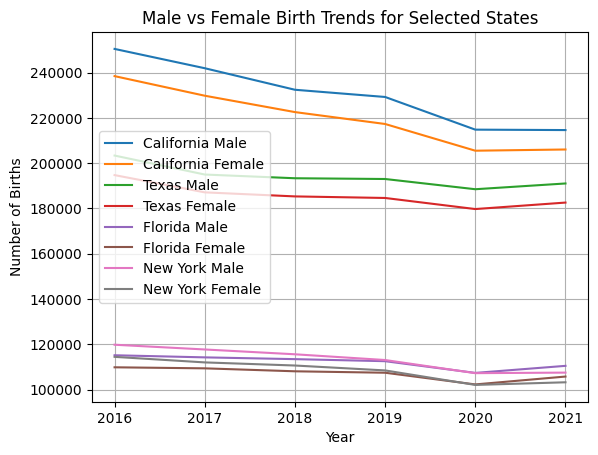

In [ ]:
top_states = ["California", "Texas", "Florida", "New York"]

for s in top_states:
    male_subset = male[male["State"] == s]
    female_subset = female[female["State"] == s]

    plt.plot(male_subset["Year"], male_subset["Number of Births"], label=f"{s} Male")
    plt.plot(female_subset["Year"], female_subset["Number of Births"], label=f"{s} Female")


plt.legend()
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.title("Male vs Female Birth Trends for Selected States")
plt.grid(True)
plt.show()


In [ ]:
top_states = ["California", "Texas", "Florida", "New York"]

male_state = {}
for r in top_states:
    male_state[r] = male[male["State"] == r]


male_state["California"]

,State,Year,Gender,Number of Births
49,California,2016,M,250419
51,California,2017,M,241898
53,California,2018,M,232389
55,California,2019,M,229203
57,California,2020,M,214778
59,California,2021,M,214592


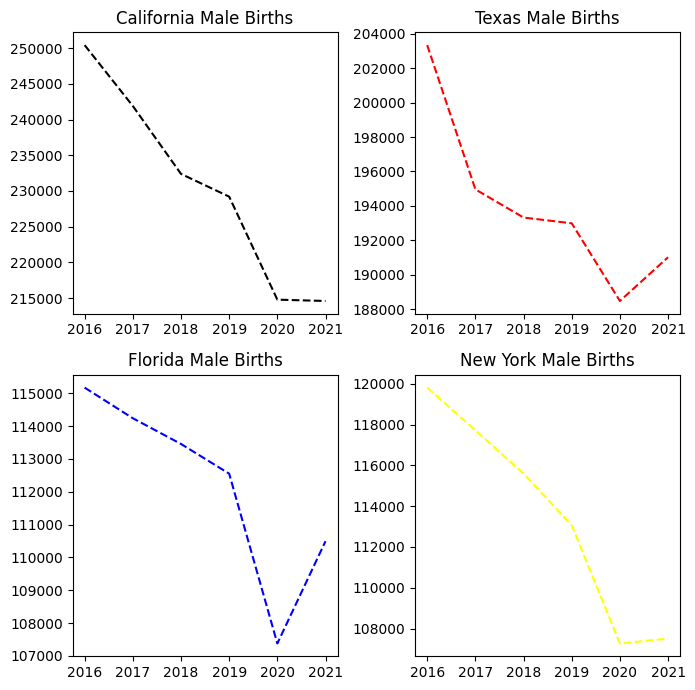

In [49]:
top_states = ["California", "Texas", "Florida", "New York"]

male_state = {}
for r in top_states:
    male_state[r] = male[male["State"] == r]

fig = plt.figure(figsize=(7,7))
ax1 = fig.add_subplot(2,2,1)   
ax2 = fig.add_subplot(2,2,2) 
ax3 = fig.add_subplot(2,2,3)  
ax4 = fig.add_subplot(2,2,4)

ax1.plot(
    male_state["California"]["Year"],
    male_state["California"]["Number of Births"],
    color="black", linestyle="dashed"
)
ax1.set_title("California Male Births")

ax2.plot(
    male_state["Texas"]["Year"],
    male_state["Texas"]["Number of Births"],
    color="red", linestyle="dashed"
)
ax2.set_title("Texas Male Births")

ax3.plot(
    male_state["Florida"]["Year"],
    male_state["Florida"]["Number of Births"],
    color="blue", linestyle="dashed"
)
ax3.set_title("Florida Male Births")

ax4.plot(
    male_state["New York"]["Year"],
    male_state["New York"]["Number of Births"],
    color="yellow", linestyle="dashed"
)
ax4.set_title("New York Male Births")

plt.tight_layout()
plt.show()


In [ ]:
state_year = birth.groupby(["State", "Year"])["Number of Births"].sum().reset_index()
state_year["YoY Change"] = state_year.groupby("State")["Number of Births"].diff()

In [56]:
state_year["Percent Change"] = state_year.groupby("State")["Number of Births"].pct_change() * 100

In [57]:
total_change = state_year.groupby("State")["Number of Births"].apply(lambda x: x.iloc[-1] - x.iloc[0])

In [ ]:
def slope(x, y):
    return np.polyfit(x, y, 1)[0]

slopes = state_year.groupby("State").apply(
    lambda df: slope(df["Year"], df["Number of Births"])
)

C:\Users\Invate\AppData\Local\Temp\ipykernel_32172\4261092411.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = state_year.groupby("State").apply(


In [60]:
state_year["Acceleration"] = state_year.groupby("State")["Number of Births"].diff().diff()

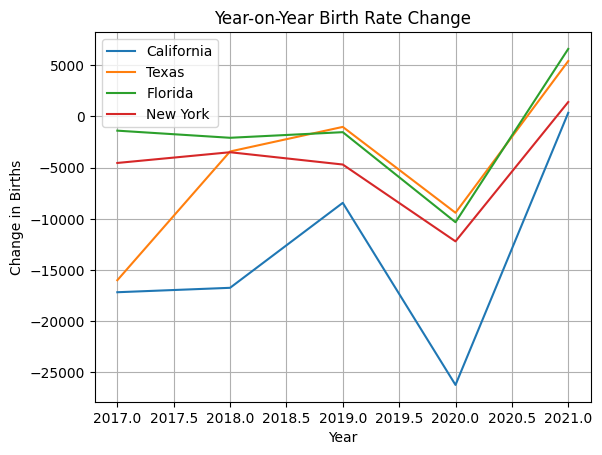

In [61]:
for s in ["California", "Texas", "Florida", "New York"]:
    subset = state_year[state_year["State"] == s]
    plt.plot(subset["Year"], subset["YoY Change"], label=s)

plt.title("Year-on-Year Birth Rate Change")
plt.xlabel("Year")
plt.ylabel("Change in Births")
plt.legend()
plt.grid(True)
plt.show()
